# Predict logP

The aim of this exercise is to compare model performance between a GNN and a supervised method to predict logP. 
Consider as a starting point one of the GNNs from session 14 (GCN, GIN, or GAT), and a supervised model of your choice (e.g., Random Forest with MACCS fingerprints).

#### Tasks:
1) Create a training and a test set
2) Build a supervised model of your choice on the training data and evaluate its performance on the test set
3) Build a GNN and compare its performance to the supervised model
4) Discuss the outcome


In [17]:
# complete imports if needed for your solution
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

from rdkit.Chem import RDKFingerprint

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, root_mean_squared_error

from rdkit import Chem

import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch_geometric.nn import GCNConv, GINConv, GATConv
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool
from torch_geometric.data import Data

Load the data from Session 11

In [18]:
df = pd.read_csv(os.path.join("..","..", "..", "lectures", "session11", "material", "esol_modified.csv")).dropna(subset=["SMILES"])
df = df.loc[df.SMILES != 'C'] # remove the one compound containing only a single atom
df.head()

,SMILES,LogS,MolWt,LogP,EState_VSA5,TPSA,NumHAcc,NumAromaticRings,HeavyAtomCount,RingCount,qed,NumHDonors,NOCount
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77,457.432,-3.10802,0.000000,202.32,12.0,1.0,32.0,3.0,0.217518,7.0,12.0
1,Cc1occc1C(=O)Nc2ccccc2,-3.30,201.225,2.84032,6.263163,42.24,2.0,2.0,15.0,2.0,0.811283,1.0,3.0
2,CC(C)=CCCC(C)=CC(=O),-2.06,152.237,2.87800,5.573105,17.07,1.0,0.0,11.0,0.0,0.343706,0.0,1.0
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87,278.354,6.29940,43.089794,0.00,0.0,5.0,22.0,5.0,0.291526,0.0,0.0
4,c1ccsc1,-1.33,84.143,1.74810,0.000000,0.00,1.0,1.0,5.0,1.0,0.448927,0.0,0.0


### Setting the stage
Split the data into training and test sets. The test set will be used to compare model performance.


In [19]:
# only split the dataframe indices
idx_train, idx_test = train_test_split(
    df.index, test_size=0.2, random_state=42
)

df_train = df.loc[idx_train].copy()
df_test = df.loc[idx_test].copy()

### Baseline supervised model
Choose a 
   - regression model (RF, SVR, kNN, Gradient Boost, ...) 
   - molecular descriptor (RDKit, Mordred, ...) or fingerprint (MACCS, Morgan, RDKit, ...)
      
Build a feature matrix and target vector. Add scaling if needed for your model.
Train the model on the training set and apply it to the test set.
Calculate performance metrics (R2, RMSE) for model performance on the test set.

Reference performance: Supervised model
Test R²: 0.7703653200775178
Test RMSE: 0.9113552811814216


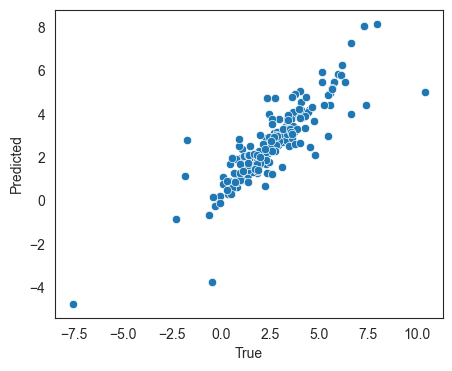

In [35]:
# use RDKit fingerprints
def RDKit_fp_from_smiles(smiles_list):
    fps = []
    for i, smi in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue
        fp = RDKFingerprint(mol)
        fps.append(np.array(fp))
    return np.array(fps)

# train model
smiles_train = df_train['SMILES'].values # Structures (SMILES)
y_train = df_train['LogP'].values # Target variable
X_train = RDKit_fp_from_smiles(smiles_train) # Calculate fingerprints (MACCS)
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# predict logP for test set
smiles_test= df_test['SMILES'].values # Structures (SMILES)
X_test = RDKit_fp_from_smiles(smiles_test) # Calculate fingerprints (MACCS)
y_test = df_test['LogP'].values # Target variable
y_pred = model.predict(X_test)

# look at performance
print("Reference performance: Supervised model")
print('Test R²:', r2_score(y_test, y_pred))
print('Test RMSE:', root_mean_squared_error(y_test, y_pred))
plt.figure(figsize=(5, 4))
sns.set_style('white')
performance = pd.DataFrame({'Predicted': y_pred, 'True': y_test})
sns.scatterplot(performance, x='True', y='Predicted')
plt.show()

### Unpervised GNN model
Choose a GNN architecture
   - GCN, GIN, or GAT
      
Transform input smiles to graph objects using the atom and bond features. Build graphs for both training and test set. Train the GNN on the training set. Adapt architecture and parameters until you are happy with the performance. Apply the trained model on the test set (once!) and calculate model performance metrics

In [36]:
# same functions as in exercises
def atom_features(atom): # Create a tensor for atom features, length = 5
    return torch.tensor([
        atom.GetAtomicNum(),
        atom.GetTotalDegree(),
        atom.GetFormalCharge(),
        int(atom.GetIsAromatic()),
        atom.GetTotalNumHs(),
    ], dtype=torch.float)

def bond_features(bond): # Create a tensor for bond features, length = 6
    bt = bond.GetBondType()
    return torch.tensor([
        bt == Chem.rdchem.BondType.SINGLE,
        bt == Chem.rdchem.BondType.DOUBLE,
        bt == Chem.rdchem.BondType.TRIPLE,
        bt == Chem.rdchem.BondType.AROMATIC,
        bond.GetIsConjugated(),
        bond.IsInRing(),
    ], dtype=torch.float)

def smiles_to_graph(smiles, y):
    mol = Chem.MolFromSmiles(smiles) # Create a RDKit mol object from the smiles

    # Calculate atom features for all atoms in the molecule
    x = torch.stack([atom_features(atom) for atom in mol.GetAtoms()], dim=0)

    # Edges
    edge_index = []
    edge_attr = []
    
    # Iterate through all bonds in the molecule
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        # Represent molecule as an undirected graph --> add both directions
        edge_index.append([i, j]) # left to right
        edge_index.append([j, i]) # right to left

        bf = bond_features(bond) # calculate bond features 
        edge_attr.append(bf)
        edge_attr.append(bf) # add two times, once for forward and once for backwards edge

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous() 
    edge_attr  = torch.stack(edge_attr, dim=0)

    # Target property: logP
    y = torch.tensor([y], dtype=torch.float)
    
    # x: atom stack, y: logP
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

Calculate graphs for train and test smiles

In [37]:
graphs_training = [smiles_to_graph(row.SMILES, row.LogP) for _, row in df_train.iterrows()]
graphs_test = [smiles_to_graph(row.SMILES, row.LogP) for _, row in df_test.iterrows()]

Choose a model - Here: Graph Isomorphism Network

In [38]:
class GINModel(torch.nn.Module):
    def __init__(self, dim_h=64):
        super().__init__()

        nn1 = torch.nn.Sequential(
            torch.nn.Linear(5, dim_h),
            torch.nn.ReLU(),
            torch.nn.Linear(dim_h, dim_h)
        )
        nn2 = torch.nn.Sequential(
            torch.nn.Linear(dim_h, dim_h),
            torch.nn.ReLU(),
            torch.nn.Linear(dim_h, dim_h)
        )
        self.conv1 = GINConv(nn1)
        self.conv2 = GINConv(nn2)
        self.lin = torch.nn.Linear(dim_h, 1)

    def forward(self, x, edge_index, batch):
        x = torch.relu(self.conv1(x, edge_index))
        x = torch.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)
        return self.lin(x).squeeze(-1)

In [45]:
def train(model, train_loader, val_loader, epochs=20, lr=0.5e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr) # lr: learning rate
    criterion = torch.nn.MSELoss() # loss function

    for epoch in range(epochs):
        model.train()
        train_losses = []

        for batch in train_loader:
            optimizer.zero_grad() # Reset gradients
            pred = model(batch.x, batch.edge_index, batch.batch) # predict on batch
            loss = criterion(pred, batch.y) # define criterion
            loss.backward() # computes the gradient of the loss
            optimizer.step() # Perform an optimization step
            train_losses.append(loss.item())

        val_loss = evaluate(model, val_loader) # evaluate re-trained model on validation data

        print(f"Epoch {epoch+1:02d} | "
              f"Train Loss = {sum(train_losses)/len(train_losses):.4f} | " # average train loss
              f"Val Loss = {val_loss:.4f}") 


def test(model, test_loader):
    test_loss = evaluate(model, test_loader)
    print(f"\nTest Loss: {test_loss:.4f}")
    
def evaluate(model, loader):
    model.eval()
    criterion = torch.nn.MSELoss()
    losses = []

    with torch.no_grad():
        for batch in loader:
            pred = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(pred, batch.y)
            losses.append(loss.item())

    return sum(losses) / len(losses)

def create_splits(graphs, train_ratio=0.8, seed=42):
    torch.manual_seed(seed)
    graphs = graphs.copy()
    permutation = torch.randperm(len(graphs))
    graphs = [graphs[i] for i in permutation]

    n = len(graphs)
    n_train = int(n * train_ratio)

    train_graphs = graphs[:n_train]
    val_graphs   = graphs[n_train:]

    return train_graphs, val_graphs

def parity_plot(model, test_loader, title="Parity Plot (Test Set)"):
    model.eval()
    preds = []
    trues = []

    with torch.no_grad():
        for batch in test_loader:
            pred = model(batch.x, batch.edge_index, batch.batch)

            # Ensure correct shapes
            pred = pred.view(-1).cpu()
            y = batch.y.view(-1).cpu()

            preds.append(pred)
            trues.append(y)

    preds = torch.cat(preds).numpy()
    trues = torch.cat(trues).numpy()
    
    print("GNN performance:")
    print('Test R²:', r2_score(trues, preds))
    print('Test RMSE:', root_mean_squared_error(trues, preds))

    # Parity plot
    plt.figure(figsize=(5,5))
    plt.scatter(trues, preds, alpha=0.6)
    plt.plot([trues.min(), trues.max()],
             [trues.min(), trues.max()],
             color='red', linestyle='--', linewidth=2)

    plt.xlabel("True logP")
    plt.ylabel("Predicted logP")
    plt.title(title)
    plt.tight_layout()
    plt.show()

Epoch 01 | Train Loss = 3.5378 | Val Loss = 3.1016
Epoch 02 | Train Loss = 2.9695 | Val Loss = 2.9756
Epoch 03 | Train Loss = 3.0059 | Val Loss = 2.9388
Epoch 04 | Train Loss = 2.9639 | Val Loss = 2.9354
Epoch 05 | Train Loss = 2.8619 | Val Loss = 3.1763
Epoch 06 | Train Loss = 2.9283 | Val Loss = 2.9157
Epoch 07 | Train Loss = 2.7733 | Val Loss = 2.9059
Epoch 08 | Train Loss = 2.7749 | Val Loss = 2.7407
Epoch 09 | Train Loss = 2.6599 | Val Loss = 2.9618
Epoch 10 | Train Loss = 2.6979 | Val Loss = 2.6146
Epoch 11 | Train Loss = 2.5941 | Val Loss = 2.6250
Epoch 12 | Train Loss = 2.4902 | Val Loss = 2.4997
Epoch 13 | Train Loss = 2.5112 | Val Loss = 2.4668
Epoch 14 | Train Loss = 2.4287 | Val Loss = 2.4703
Epoch 15 | Train Loss = 2.3470 | Val Loss = 2.3426
Epoch 16 | Train Loss = 2.3670 | Val Loss = 2.6652
Epoch 17 | Train Loss = 2.4452 | Val Loss = 2.5353
Epoch 18 | Train Loss = 2.2951 | Val Loss = 2.4414
Epoch 19 | Train Loss = 2.2868 | Val Loss = 2.1692
Epoch 20 | Train Loss = 2.1665 

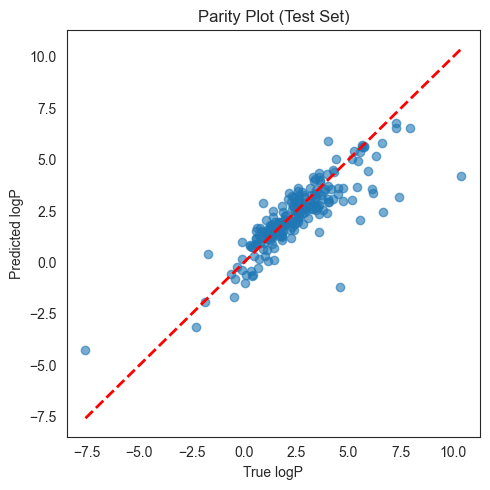

In [46]:
# load train and validation graphs
graphs_train, graphs_val = create_splits(graphs_training)
train_loader = DataLoader(graphs_train, batch_size=32, shuffle=True)
val_loader   = DataLoader(graphs_val, batch_size=32)

test_loader = DataLoader(graphs_test)

# load model
gin = GINModel()

# Train model
epochs = 500
train(gin, train_loader, val_loader, epochs=epochs)

# Evaluate model
parity_plot(gin, test_loader)

### Discussion points
1) Which model (supervised or unsupervised) performed better on the test set, and why?
2) What did you try to improve model performance of your GNN? What did work, what did not work?
3) Which challenges did you face in the process of building the models?
4) Which of your two models would you recommend to a chemist for predicting logP, and why?